#  My Healthier Starbucks: Small Choices, Big Impact

### 1. Background

Every time our family is out on the road for a weekend lunch or travel, we always love to stop by for a starbucks drink (hot or cold) depending on the season. We also try to stay mindful of our food and beverage choices, balancing enjoyment with health consciousness.

Since, Starbucks is undoubtedly one of our favorite coffee shops, I became curious:

##### *Could we continue enjoying our drinks while improving our choices?*

That curiosity led me to explore their nutrition data to better educate our choices and create more awareness for all starbucks beverage lovers out there.

### 2. Introduction & Contents

Our goal is to make healthier choices without giving up on the beverages we enjoy. With that in mind, we will explore the following ideas. 

##### A. Exploring Available Beverage Options:
Understanding variation between different drink categories.
##### B. Understanding Sugar:
Identifying where sugar shows up and how to think about it.
##### C. Sugar Vs. Calories:
Exploring the relationship between sugar and calories.
##### D. Healthier Choice within Category:
Using categories as a shortcut for better decisions.
##### E. Bigger Picture
Seeing the full range of choices available.
##### F. Simplifying Decisions
Focusing on what matter most.
##### G. Main Take Home Messages
Key takeaways you can apply right away.

***Note: We will be focusing on sugar and calories to determine our healthier options for this analysis.***

### 3. Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

starbucks = pd.read_csv('starbucks.csv')
#Check available columns
print(starbucks.head())
#Check for nulls
print(starbucks.info())

         Beverage_category       Beverage Original_Beverage_prep  \
0                   Coffee  Brewed Coffee                  Short   
1                   Coffee  Brewed Coffee                   Tall   
2                   Coffee  Brewed Coffee                 Grande   
3                   Coffee  Brewed Coffee                  Venti   
4  Classic Espresso Drinks    Caffè Latte      Short Nonfat Milk   

       Beverage_prep  Calories   Total Fat (g)  Trans Fat (g)   \
0              Short         3             0.1             0.0   
1               Tall         4             0.1             0.0   
2             Grande         5             0.1             0.0   
3              Venti         5             0.1             0.0   
4  Short Nonfat Milk        70             0.1             0.1   

   Saturated Fat (g)   Sodium (mg)   Total Carbohydrates (g)   \
0                0.0             0                          5   
1                0.0             0                         10   

### 4. Exploratory Data Analysis & Insights

#### A. Exploring Available Beverage Options

One of the big reasons we are drawn to Starbucks other than quality coffee is the variety of options to choose from which for most part can also be customized according to ones needs. So, let's explore the different beverage categories along with calories for each of them.

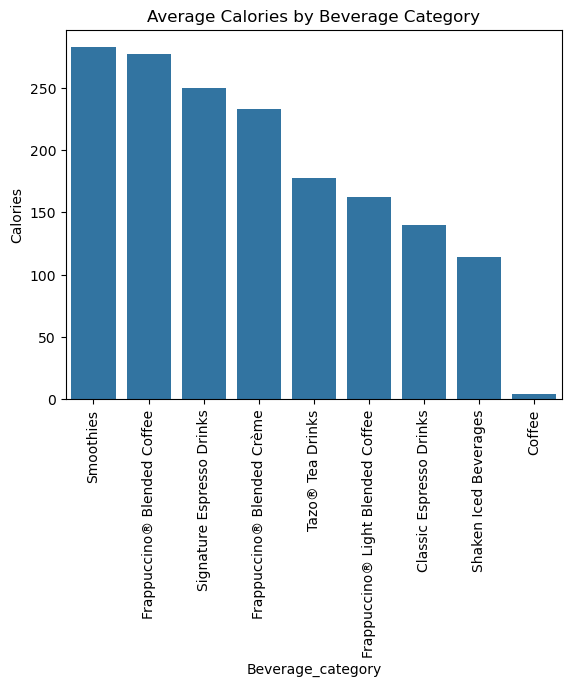

In [2]:
#plot beverage categories by avg calories in each of them
avg_calories = starbucks.groupby('Beverage_category')['Calories'].mean().sort_values(ascending=False)
_=sns.barplot(avg_calories)
_=plt.title("Average Calories by Beverage Category")
_=plt.xticks(rotation=90)
plt.show()

As we can see from the chart above, we can always shift to a lower calorie beverage category or ask the barista if there are ways to customize our favorite drink to lower the overall calorie intake.

#### B. Understanding Sugar

Beverage sweetness plays a huge role for many of us in determining our liking for it. However, we know that excess sugar consumption is not good for health. Let's look at sugar content in starbucks beverages to make more intentional choices next time we get one.

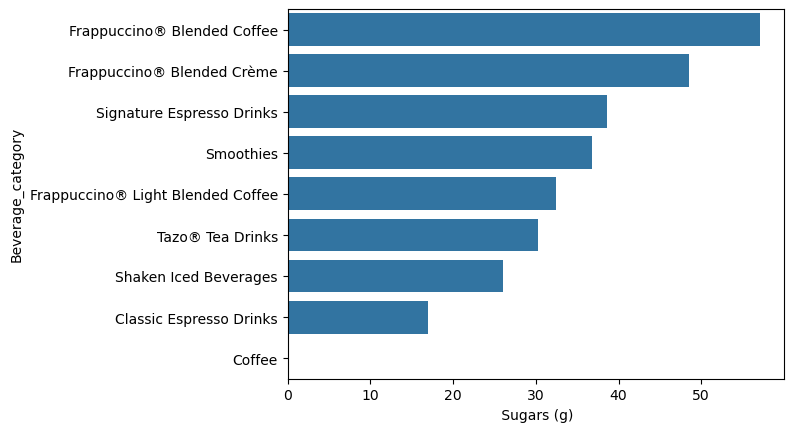

In [3]:
#barplot for beverage category by sugar in grams (High to Low)
avg_sugar_grams = starbucks.groupby('Beverage_category')[' Sugars (g)'].mean().sort_values(ascending=False)
sns.barplot(data = avg_sugar_grams, orient='h')
plt.show()

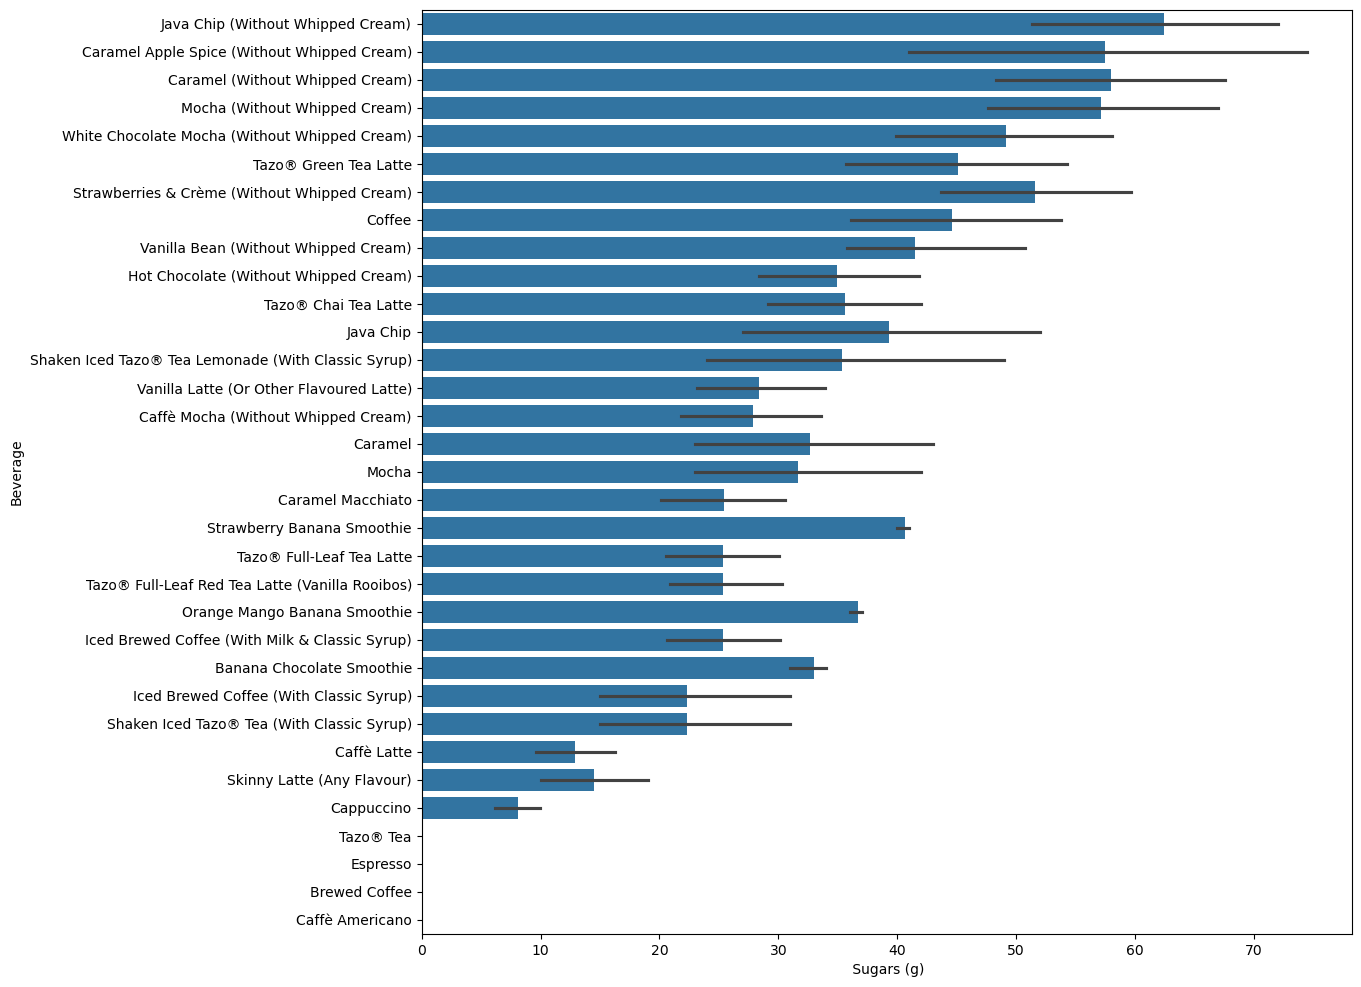

In [4]:
#barplot for beverages by sugar in grams (High to Low)
plt.figure(figsize=(12,12))
sns.barplot(data = starbucks.sort_values(by=" Sugars (g)", ascending=False), x=" Sugars (g)", y="Beverage")
plt.show()

Beverages from certain categories like Frappuccino,  Signature Espresso Drinks and Smoothies are high in sugar and calories. It is best to have them as an occasional treat and stick to coffee, cappuccino, some teas and espresso for daily routines.

#### C. Sugar Vs. Calories

It would be interesting to see the relationship between sugar and calories in the beverages as we want both to be lower for healthier options.

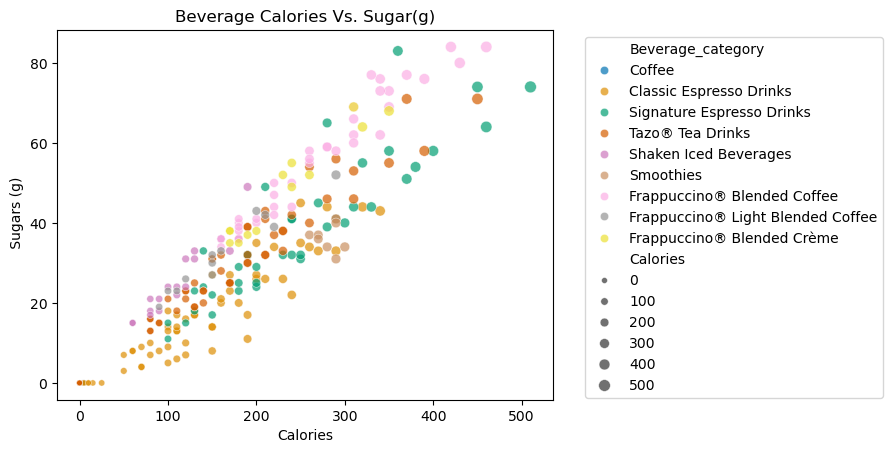

In [5]:
#Scatter Plot for Sugar Vs. Calories
sns.scatterplot(data=starbucks, x="Calories", y=" Sugars (g)", hue="Beverage_category", size="Calories", alpha=0.7, palette="colorblind")
plt.title("Beverage Calories Vs. Sugar(g)")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

There seems to be a clear relationship between sugar and calories. They certainly go hand in hand. As sugar increases, calories also increase. Some of the frappuccino belnded drinks, Signature Espresso Drinks and Tazo Tea Drinks top the list for high sugar and calories as previously seen.

So, cutting down on sugar in the beverages and choosing beverage categories with lower sugar like Classic Espresso Drinks and some teas seems to be a healthier way to go and takes care of calories as well.

Making simple decisions like choosing the lower sugar categories can have a big impact on our health over time!

#### D. Healthier Choice within Category

Let us see how we can make smarter choices by lowest sugar/calorie beverage within each category.

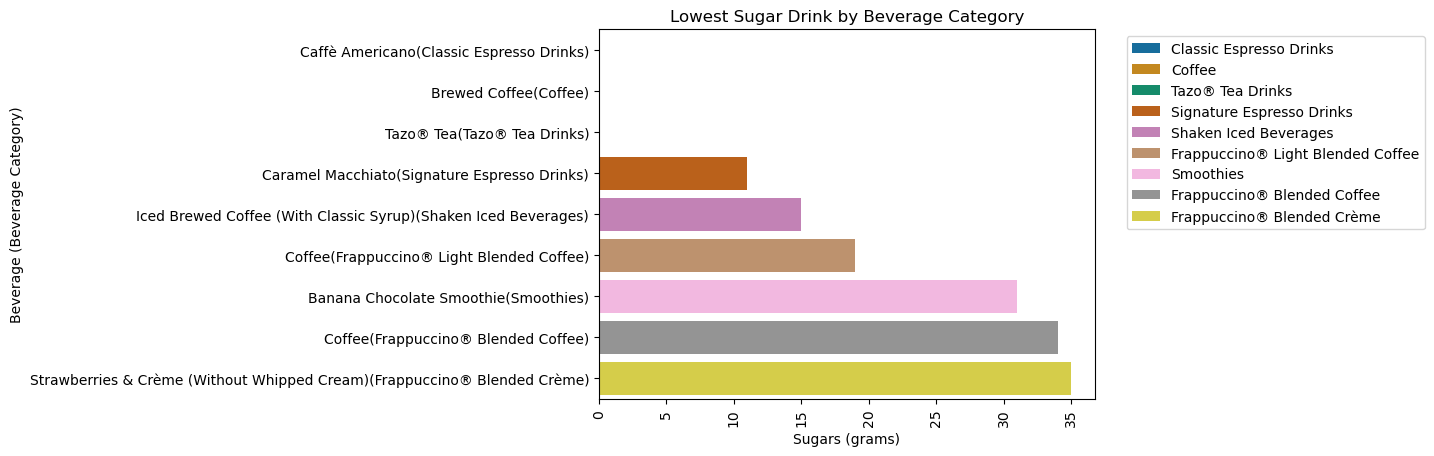

In [6]:
#bar plot for healthiest beverage from each beverage category
healthy_bevs = starbucks.sort_values([" Sugars (g)", "Calories"]).groupby("Beverage_category").first().reset_index()
healthy_bevs['label']=healthy_bevs["Beverage"] + "(" + healthy_bevs["Beverage_category"] + ")"
healthy_bevs=healthy_bevs.sort_values(by=" Sugars (g)")
sns.barplot(healthy_bevs, x=" Sugars (g)", y="label", hue="Beverage_category", palette="colorblind")
plt.title("Lowest Sugar Drink by Beverage Category")
plt.xlabel("Sugars (grams)")
plt.ylabel("Beverage (Beverage Category)")
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

These are the lowest sugar drinks by each beverage category. Depending on the category, we are in a mood for, we can always go with the lowest sugar option or customize it slightly per our need without adding too much sugar/calories.

#### E. Bigger Picture

Basically, as we have seen from the charts above, Starbucks offers a range of beverages across all categories which are also customizable making it easy for us to select a healthier option.

Based on the histogram below, we see that there is a wide range of sugar across drinks so no matter our preference we can always choose something we enjoy while being health conscious. Now, that feels empowering!

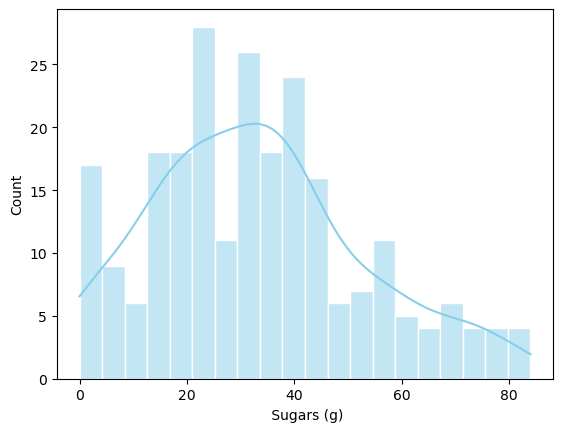

In [7]:
#Histogram of Sugar Content across Beverages
sns.histplot(starbucks[" Sugars (g)"], bins=20, kde=True, color="skyblue", edgecolor="white")
plt.show()

#### F. Simplifying Decisions

We can get lost with so much nutrition information available about the beverages. So, how do we simplify it?
Let us first look at the correlation between calories, sugars, fat and caffiene.

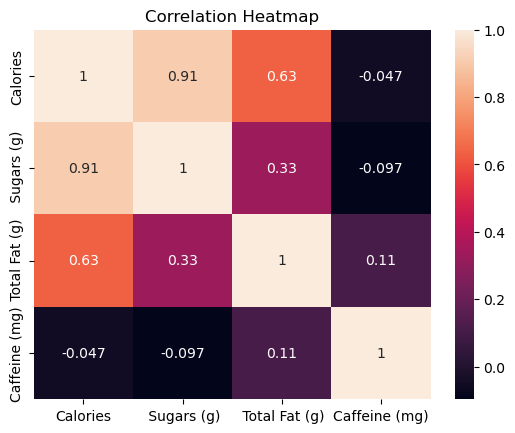

In [10]:
#correlation matrix for key nutrition information of beverages
starbucks["Caffeine (mg)"]=pd.to_numeric(starbucks["Caffeine (mg)"], errors='coerce')
corr= starbucks[["Calories"," Sugars (g)", " Total Fat (g)", "Caffeine (mg)"]].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

We can see from the heatmap above that sugar has the strongest correlation with calories. So, to simply things, we can always just focus on sugar to begin with for our beverage choice.

#### G. Main Take Home Messages

The reason for this whole exercise was to empower us in making healthier beverage choice when we visit our favorite Starbucks. 
Here is what we learned.

1. We have more control on our beverage choice than we think. 
2. Small choices can have a meaningful health impact.
3. Simplicity (i.e focusing on sugar content to begin with) will help ensure consistency.
4. Balance certainly works better than complete restriction.

So, bottom line is that we do not have to give up our Starbucks completely.
Just by making smarter decisions by focusing on sugar/calorie content in beverages, we can enjoy our drinks while ensuring better health.